# YOLO26x Step by Step: From PyTorch to a GPU-Resident Video Pipeline

**Speaker:** Zihao Mu, Member of Technical Staff, Product Application Engineering, AMD

This notebook keeps the released YOLO + VLM workflow unchanged. It opens the black box one layer at a time and measures where time is spent:

```text
YOLO26x .pt
  -> static ONNX
  -> Ultralytics + ONNX Runtime MIGraphX EP
  -> explicit H2D / D2H transfer lab
  -> resident GPU buffers + I/O Binding
  -> GPU preprocess + GPU NMS
  -> rocDecode + direct VA-API encode
  -> Qwen3-VL as a separately measured semantic stage
```

The goal is not to memorize one FPS number. The goal is to identify each hardware boundary, measure it with synchronization, then remove or overlap the expensive boundaries without changing model correctness.

## 1. Verify the fixed environment

The workshop image already contains the checkpoint, release ONNX, MIGraphX cache, Qwen3-VL weights, and the patched Ultralytics backend. This cell still performs the complete model/GPU/runtime validation, but keeps verbose output in `output/logs/environment.log` and presents the verified environment with real input frames.

Environment validation: complete (full log: /workspace/output/step_by_step/logs/environment.log)


**Runtime ready:** `AMD Radeon PRO W7900D` / `gfx1100`; OpenCV HIP devices: `1`; model mapping: `/workspace/models` -> `/workspace/models` (existing model directory).

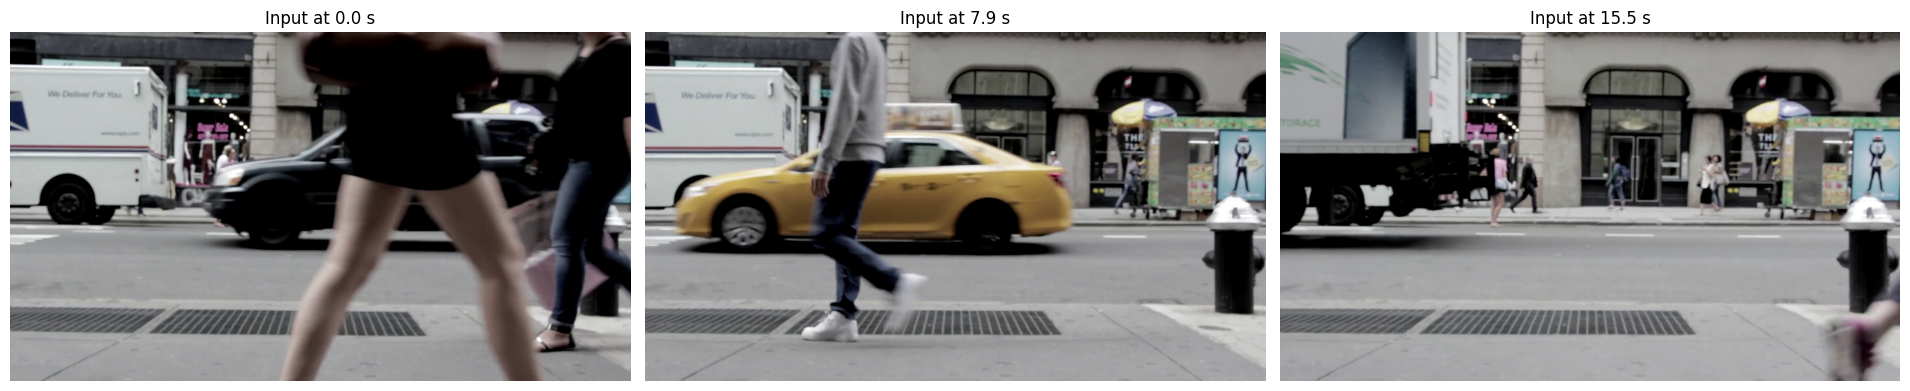

### Verified model and backend assets

- `yolo26x.pt`
- `yolo26x.onnx`
- `Qwen3-VL-8B-Instruct-Q8_0.gguf`
- `mmproj-F16.gguf`
- ORT providers: `MIGraphXExecutionProvider, CPUExecutionProvider`
- MIGraphX cache: `/workspace/models/ort-migraphx-cache`
- Writable output: `/workspace/output/step_by_step`

In [24]:
import importlib
import json
import os
import sys
from pathlib import Path


NOTEBOOK_DIR = Path.cwd().resolve()
BAKED_SEED = Path(os.environ.get(
    "ULTRALYTICS_WORKSHOP_SEED_DIR", "/opt/ultralytics-yolo26/seed"
)).resolve()
BAKED_MODELS = Path(os.environ.get(
    "ULTRALYTICS_BAKED_MODEL_DIR", "/opt/ultralytics-yolo26/models"
)).resolve()


def is_package_root(path: Path) -> bool:
    return (
        (path / "scripts/notebook_env.py").is_file()
        and (path / "src").is_dir()
        and (path / "data").is_dir()
    )


def find_package_root() -> Path:
    candidates = []
    for variable in ("ULTRALYTICS_YOLO26_ROOT", "OPENCV_AMD_END2END_ROOT"):
        if os.environ.get(variable):
            candidates.append(Path(os.environ[variable]).expanduser())
    candidates.extend([NOTEBOOK_DIR, *NOTEBOOK_DIR.parents])
    candidates.extend(Path(value) for value in sys.path if value)
    candidates.append(BAKED_SEED)

    visited = set()
    for origin in candidates:
        try:
            resolved = origin.resolve()
        except (OSError, RuntimeError):
            continue
        for candidate in (resolved, *resolved.parents):
            if candidate in visited:
                continue
            visited.add(candidate)
            if is_package_root(candidate):
                return candidate
    raise FileNotFoundError(
        "Cannot find the ultralytics_yolo26 sources from the current directory "
        f"({NOTEBOOK_DIR}) or immutable seed ({BAKED_SEED})."
    )


def map_baked_models(work_dir: Path, source_dir: Path) -> tuple[Path, str]:
    required = (
        "yolo26x.pt",
        "yolo26x.onnx",
        "Qwen3-VL-8B-Instruct-Q8_0.gguf",
        "mmproj-F16.gguf",
    )
    missing = [name for name in required if not (source_dir / name).is_file()]
    if missing:
        raise FileNotFoundError(
            f"Baked model directory is incomplete: {source_dir}; missing={missing}"
        )

    alias = work_dir / "models"
    if alias.is_symlink():
        if alias.resolve() != source_dir:
            alias.unlink()
            alias.symlink_to(source_dir, target_is_directory=True)
        return alias.resolve(), "symlink"
    if alias.exists():
        if alias.resolve() == source_dir:
            return source_dir, "existing mapping"
        local_missing = [name for name in required if not (alias / name).is_file()]
        if local_missing:
            raise RuntimeError(
                f"Cannot map baked models: {alias} is an existing real path and "
                f"does not contain the release model set (missing={local_missing}). "
                "Remove that mount/directory or set ULTRALYTICS_YOLO26_MODEL_DIR "
                "to a complete model set."
            )
        return alias.resolve(), "existing model directory"

    try:
        alias.symlink_to(source_dir, target_is_directory=True)
        return alias.resolve(), "symlink"
    except OSError as error:
        print(
            f"[bootstrap] Cannot create {alias} -> {source_dir}: {error}. "
            "Using the immutable model directory directly."
        )
        return source_dir, "direct fallback"


ROOT = find_package_root()
MODEL_DIR, MODEL_MAPPING = map_baked_models(NOTEBOOK_DIR, BAKED_MODELS)
OUTPUT_DIR = NOTEBOOK_DIR / "output" / "step_by_step"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

os.environ["ULTRALYTICS_YOLO26_ROOT"] = str(ROOT)
os.environ["ULTRALYTICS_YOLO26_MODEL_DIR"] = str(MODEL_DIR)
os.environ["ULTRALYTICS_YOLO26_OUTPUT_DIR"] = str(OUTPUT_DIR)
os.environ["ULTRALYTICS_MIGRAPHX_CACHE_ROOT"] = str(
    MODEL_DIR / "ort-migraphx-cache"
)
os.environ.setdefault("HF_ENDPOINT", "https://hf-mirror.com")
for value in (str(ROOT), str(ROOT / "src")):
    if value not in sys.path:
        sys.path.insert(0, value)

from scripts import notebook_env as env
env = importlib.reload(env)
from IPython.display import Markdown, display
from scripts.model_setup import ensure_models, model_status
from scripts import notebook_helpers
notebook_helpers = importlib.reload(notebook_helpers)
from scripts.notebook_helpers import (
    capture_log,
    frame_at,
    show_bgr,
    show_bgr_grid,
    show_video,
    video_info,
)
from scripts.validate_runtime import validate

delivery_mode = (
    "baked/offline verification"
    if os.environ.get("ULTRALYTICS_WORKSHOP_BUNDLE") == "baked"
    else "development fallback download"
)
with capture_log(env.OUTPUT / "logs/environment.log", "Environment validation"):
    models = ensure_models(env.MODELS, progress=True)
    runtime = validate(require_models=True, require_vlm=False)

source_info = video_info(env.SOURCE_VIDEO)
preview_times = [
    0.0,
    source_info["duration_seconds"] / 2,
    max(0.0, source_info["duration_seconds"] - 0.2),
]
source_preview_frames = [frame_at(env.SOURCE_VIDEO, seconds) for seconds in preview_times]
first_frame = source_preview_frames[0]
display(Markdown(
    f"**Runtime ready:** `{runtime['torch_gpu']}` / `{runtime['gpu_arch']}`; "
    f"OpenCV HIP devices: `{runtime['opencv_hip_devices']}`; model mapping: "
    f"`{NOTEBOOK_DIR / 'models'}` -> `{MODEL_DIR}` ({MODEL_MAPPING})."
))
show_bgr_grid(
    source_preview_frames,
    [f"Input at {seconds:.1f} s" for seconds in preview_times],
    columns=3,
)

native_build = ROOT / "native/build"
if native_build.is_dir():
    native_build_text = str(native_build)
    if native_build_text not in sys.path:
        sys.path.insert(0, native_build_text)
    existing_pythonpath = os.environ.get("PYTHONPATH", "")
    pythonpath_entries = existing_pythonpath.split(":") if existing_pythonpath else []
    if native_build_text not in pythonpath_entries:
        os.environ["PYTHONPATH"] = ":".join([native_build_text, *pythonpath_entries])

verified_model_names = [Path(item["path"]).name for item in models if item["ready"]]
display(Markdown(
    "### Verified model and backend assets\n\n"
    + "\n".join(f"- `{name}`" for name in verified_model_names)
    + "\n"
    + f"- ORT providers: `{', '.join(runtime['onnxruntime_providers'])}`\n"
    + f"- MIGraphX cache: `{runtime['migraphx_cache']}`\n"
    + f"- Writable output: `{env.OUTPUT}`"
))

## 2. Convert the YOLO26x checkpoint from PyTorch to static ONNX

The export is deliberately static: batch 1, `640 x 640`, and an end-to-end `[1, 300, 6]` output. Static shapes let MIGraphX compile and reuse a stable program.

The checkpoint is copied into `output/export/` first, so the export cannot overwrite the immutable release model. `RUN_EXPORT=1` is the default for this teaching notebook. Set it to `0` only when reusing the verified release ONNX.

PyTorch inference and ONNX export: complete (full log: /workspace/output/step_by_step/logs/pt_to_onnx.log)


**Conversion result:** `[1, 3, 640, 640]` -> `[1, 300, 6]`; 212.9 MiB; exported in `2.52 s`.

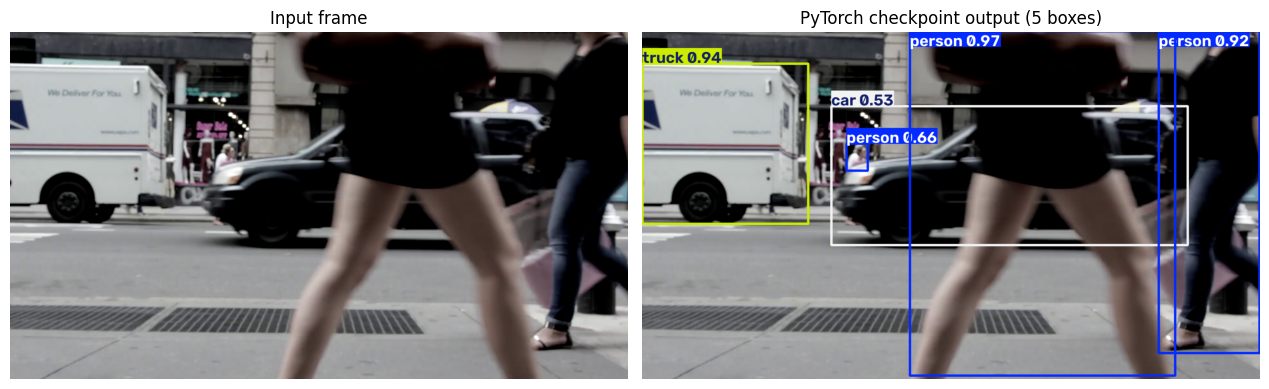

In [25]:
import gc
import hashlib
import shutil
import time

import onnx
import torch
from ultralytics import YOLO

RUN_EXPORT = os.environ.get("RUN_EXPORT", "1") == "1"
export_dir = env.OUTPUT / "export"
export_dir.mkdir(parents=True, exist_ok=True)

with capture_log(env.OUTPUT / "logs/pt_to_onnx.log", "PyTorch inference and ONNX export"):
    pt_model = YOLO(str(env.YOLO_CHECKPOINT))
    pt_result = pt_model.predict(
        first_frame,
        device=0,
        half=True,
        imgsz=640,
        conf=0.5,
        iou=0.45,
        verbose=False,
    )[0]
    if RUN_EXPORT:
        checkpoint_copy = export_dir / env.YOLO_CHECKPOINT.name
        shutil.copy2(env.YOLO_CHECKPOINT, checkpoint_copy)
        export_started = time.perf_counter()
        export_model = YOLO(str(checkpoint_copy))
        workshop_onnx = Path(export_model.export(
            format="onnx",
            imgsz=640,
            batch=1,
            dynamic=False,
            simplify=False,
            device=0,
        )).resolve()
        export_seconds = time.perf_counter() - export_started
        del export_model
    else:
        workshop_onnx = env.YOLO_ONNX
        export_seconds = None

pt_plot = pt_result.plot()
onnx_model = onnx.load(str(workshop_onnx), load_external_data=False)
onnx.checker.check_model(onnx_model)
input_shape = [dim.dim_value for dim in onnx_model.graph.input[0].type.tensor_type.shape.dim]
output_shape = [dim.dim_value for dim in onnx_model.graph.output[0].type.tensor_type.shape.dim]
metadata = {item.key: item.value for item in onnx_model.metadata_props}
onnx_sha256 = hashlib.sha256(workshop_onnx.read_bytes()).hexdigest()
export_record = {
    "checkpoint": str(env.YOLO_CHECKPOINT),
    "onnx": str(workshop_onnx),
    "export_seconds": None if export_seconds is None else round(export_seconds, 3),
    "bytes": workshop_onnx.stat().st_size,
    "sha256": onnx_sha256,
    "input_shape": input_shape,
    "output_shape": output_shape,
    "dynamic": False,
    "task": metadata.get("task"),
    "end2end": metadata.get("end2end"),
}
export_summary = (
    f"exported in `{export_seconds:.2f} s`"
    if export_seconds is not None
    else "reused the verified release ONNX"
)
display(Markdown(
    f"**Conversion result:** `{input_shape}` -> `{output_shape}`; "
    f"{workshop_onnx.stat().st_size / 1024**2:.1f} MiB; {export_summary}."
))
show_bgr_grid(
    [first_frame, pt_plot],
    ["Input frame", f"PyTorch checkpoint output ({len(pt_result.boxes)} boxes)"],
    columns=2,
)
assert input_shape == [1, 3, 640, 640]
assert output_shape == [1, 300, 6]
del pt_result, pt_model
gc.collect()
torch.cuda.empty_cache()

## 3. Run ONNX through the Ultralytics MIGraphX backend

Ultralytics still owns model loading and `predict()`. The workshop fork selects `MIGraphXExecutionProvider`, enables FP16, and uses GPU I/O Binding.

This cell reports three different costs:

- model object construction;
- first prediction, which includes backend initialization and cache work;
- steady high-level `predict()` latency, which includes image preprocessing, inference, postprocessing, and result construction.

By default, the ONNX produced in the previous cell runs through MIGraphX with a writable cache under `output/export/`. Set `USE_FRESH_EXPORT=0` to use the hash-verified release ONNX and its prepared cache instead.

Compiling/loading the MIGraphX program, then measuring steady-state prediction...

ONNX/MIGraphX inference: complete (full log: /workspace/output/step_by_step/logs/onnx_migraphx.log)


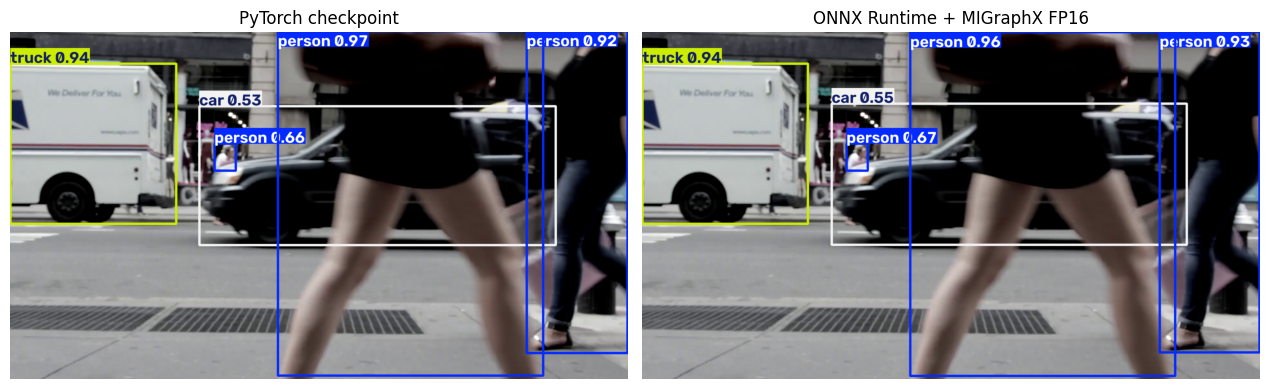

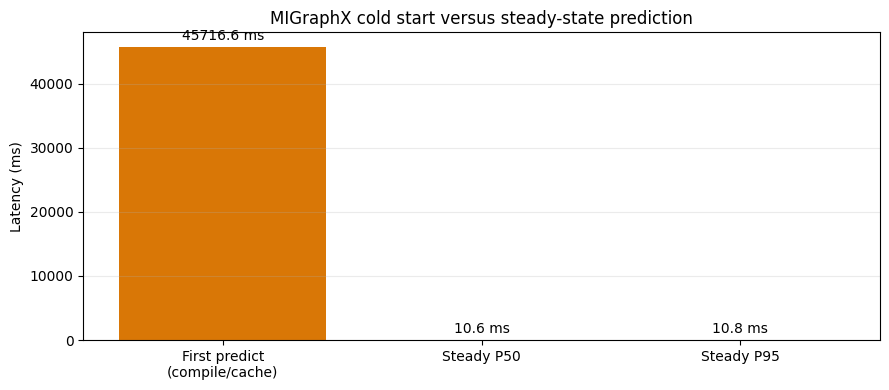

**Backend:** `MIGraphXExecutionProvider` / FP16 / I/O Binding. Steady P50 `10.62 ms` (94.2 calls/s); detected `5` objects.

In [26]:
import gc
import math
import statistics

import matplotlib.pyplot as plt
import torch

from migraphx_cache import prepare_cache

USE_FRESH_EXPORT = os.environ.get(
    "USE_FRESH_EXPORT", "1" if RUN_EXPORT else "0"
) == "1"
deployment_onnx = workshop_onnx if USE_FRESH_EXPORT else env.YOLO_ONNX
deployment_sha256 = hashlib.sha256(deployment_onnx.read_bytes()).hexdigest()
deployment_cache_root = (
    export_dir / "ort-migraphx-cache"
    if USE_FRESH_EXPORT
    else env.MIGRAPHX_CACHE
)
deployment_cache_root.mkdir(parents=True, exist_ok=True)
os.environ["ULTRALYTICS_MIGRAPHX_CACHE_ROOT"] = str(deployment_cache_root)
display(Markdown("Compiling/loading the MIGraphX program, then measuring steady-state prediction..."))

with capture_log(env.OUTPUT / "logs/onnx_migraphx.log", "ONNX/MIGraphX inference"):
    cache_dir, cache_identity = prepare_cache(
        deployment_onnx, deployment_cache_root, 0
    )
    construct_started = time.perf_counter()
    yolo = YOLO(str(deployment_onnx), task="detect")
    construct_ms = (time.perf_counter() - construct_started) * 1000

    torch.cuda.synchronize()
    first_started = time.perf_counter()
    result = yolo.predict(
        first_frame,
        device=0,
        half=True,
        imgsz=640,
        conf=0.5,
        iou=0.45,
        verbose=False,
    )[0]
    torch.cuda.synchronize()
    first_predict_ms = (time.perf_counter() - first_started) * 1000

    predict_samples_ms = []
    for _ in range(12):
        torch.cuda.synchronize()
        started = time.perf_counter()
        result = yolo.predict(
            first_frame,
            device=0,
            half=True,
            imgsz=640,
            conf=0.5,
            iou=0.45,
            verbose=False,
        )[0]
        torch.cuda.synchronize()
        predict_samples_ms.append((time.perf_counter() - started) * 1000)

backend = yolo.predictor.model.backend
assert backend.provider == "MIGraphXExecutionProvider"
assert backend.use_io_binding and backend.migraphx_fp16
ordered_predict = sorted(predict_samples_ms)
predict_p50_ms = statistics.median(predict_samples_ms)
predict_p95_ms = ordered_predict[math.ceil(len(ordered_predict) * 0.95) - 1]
result_plot = result.plot()
backend_timing = {
    "onnx": str(deployment_onnx),
    "fresh_export_selected": USE_FRESH_EXPORT,
    "provider": backend.provider,
    "io_binding": backend.use_io_binding,
    "migraphx_fp16": backend.migraphx_fp16,
    "cache": str(cache_dir),
    "construct_ms": round(construct_ms, 3),
    "first_predict_ms": round(first_predict_ms, 3),
    "steady_predict_p50_ms": round(predict_p50_ms, 3),
    "steady_predict_p95_ms": round(predict_p95_ms, 3),
    "single_call_rate_from_p50": round(1000 / predict_p50_ms, 1),
    "boxes": len(result.boxes),
}
show_bgr_grid(
    [pt_plot, result_plot],
    ["PyTorch checkpoint", "ONNX Runtime + MIGraphX FP16"],
    columns=2,
)
figure, axis = plt.subplots(figsize=(9, 4))
labels = ["First predict\n(compile/cache)", "Steady P50", "Steady P95"]
values = [first_predict_ms, predict_p50_ms, predict_p95_ms]
bars = axis.bar(labels, values, color=["#d97706", "#007c91", "#4f6d7a"])
axis.bar_label(bars, fmt="%.1f ms", padding=3)
axis.set_ylabel("Latency (ms)")
axis.set_title("MIGraphX cold start versus steady-state prediction")
axis.grid(axis="y", alpha=0.25)
figure.tight_layout()
plt.show()
display(Markdown(
    f"**Backend:** `{backend.provider}` / FP16 / I/O Binding. "
    f"Steady P50 `{predict_p50_ms:.2f} ms` ({1000 / predict_p50_ms:.1f} calls/s); "
    f"detected `{len(result.boxes)}` objects."
))
del result, yolo, backend
gc.collect()
torch.cuda.empty_cache()

## 4. Measure the transfer tax: H2D and D2H

`H2D` copies host memory to GPU memory. `D2H` copies GPU memory back to the host. These synchronized measurements time one preallocated copy at a time; allocation and random-data generation are outside the timed region.

We compare:

- a full `1920 x 1080` RGB frame;
- a `1 x 3 x 640 x 640` FP32 model input;
- the compact `1 x 300 x 6` FP32 model output;
- pageable and pinned host memory.

Pinned memory can enable asynchronous DMA, but `non_blocking=True` alone does not make a dependency disappear. This cell synchronizes after every copy to measure completion rather than enqueue time. The exact numbers are machine-specific; the payload-size contrast is the transferable lesson.

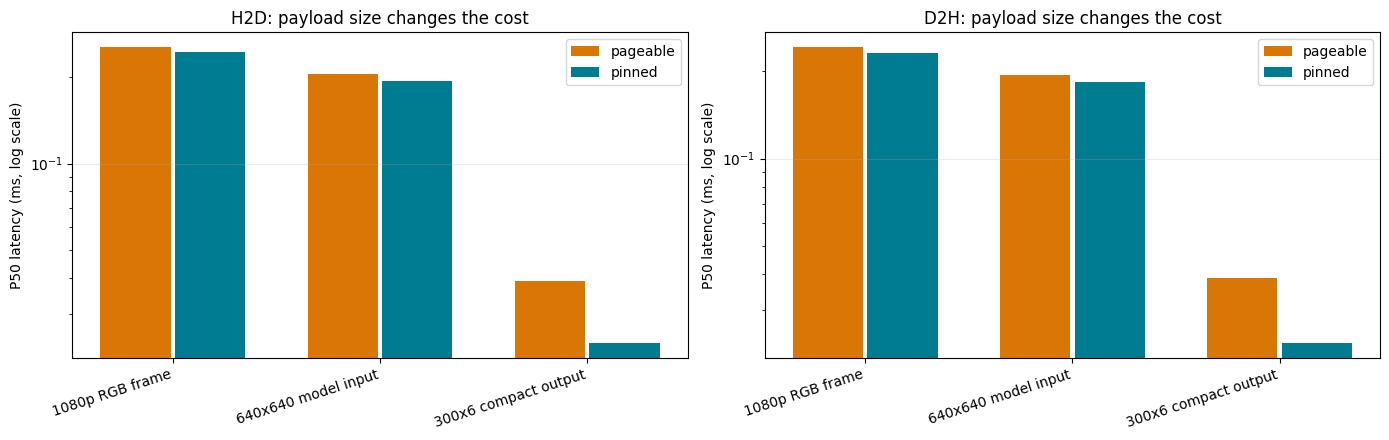

,payload,direction,host_memory,payload_MiB,p50_ms,p95_ms
0,1080p RGB frame,H2D,pageable,5.933,0.2540,0.2578
1,1080p RGB frame,H2D,pinned,5.933,0.2434,0.2448
2,1080p RGB frame,D2H,pageable,5.933,0.2424,0.3466
3,1080p RGB frame,D2H,pinned,5.933,0.2311,0.2631
4,640x640 model input,H2D,pageable,4.688,0.2042,0.2070
5,640x640 model input,H2D,pinned,4.688,0.1943,0.1957
6,640x640 model input,D2H,pageable,4.688,0.1950,0.1962
7,640x640 model input,D2H,pinned,4.688,0.1844,0.1865
8,300x6 compact output,H2D,pageable,0.007,0.0389,0.0396
9,300x6 compact output,H2D,pinned,0.007,0.0237,0.0243


In [27]:
import pandas as pd


def percentile(values, fraction):
    ordered = sorted(values)
    return ordered[math.ceil(len(ordered) * fraction) - 1]


def measure_transfer(operation, payload_bytes, repeats=50, warmup=5):
    for _ in range(warmup):
        operation()
        torch.cuda.synchronize()
    samples_ms = []
    for _ in range(repeats):
        torch.cuda.synchronize()
        started = time.perf_counter()
        operation()
        torch.cuda.synchronize()
        samples_ms.append((time.perf_counter() - started) * 1000)
    p50_ms = statistics.median(samples_ms)
    p95_ms = percentile(samples_ms, 0.95)
    return {
        "p50_ms": round(p50_ms, 4),
        "p95_ms": round(p95_ms, 4),
        "effective_GBps": round(payload_bytes / (p50_ms * 1_000_000), 3),
        "share_of_25fps_budget_pct": round(p50_ms / 40.0 * 100, 2),
    }


transfer_cases = [
    ("1080p RGB frame", (1080, 1920, 3), torch.uint8),
    ("640x640 model input", (1, 3, 640, 640), torch.float32),
    ("300x6 compact output", (1, 300, 6), torch.float32),
]
transfer_results = []
for payload_name, shape, dtype in transfer_cases:
    pageable_source = torch.empty(shape, dtype=dtype, device="cpu")
    pinned_source = torch.empty(shape, dtype=dtype, device="cpu", pin_memory=True)
    gpu_buffer = torch.empty(shape, dtype=dtype, device="cuda:0")
    pageable_destination = torch.empty(shape, dtype=dtype, device="cpu")
    pinned_destination = torch.empty(shape, dtype=dtype, device="cpu", pin_memory=True)
    payload_bytes = gpu_buffer.numel() * gpu_buffer.element_size()
    operations = [
        ("H2D", "pageable", lambda: gpu_buffer.copy_(pageable_source, non_blocking=False)),
        ("H2D", "pinned", lambda: gpu_buffer.copy_(pinned_source, non_blocking=True)),
        ("D2H", "pageable", lambda: pageable_destination.copy_(gpu_buffer, non_blocking=False)),
        ("D2H", "pinned", lambda: pinned_destination.copy_(gpu_buffer, non_blocking=True)),
    ]
    for direction, host_memory, operation in operations:
        transfer_results.append({
            "payload": payload_name,
            "direction": direction,
            "host_memory": host_memory,
            "payload_MiB": round(payload_bytes / 1024**2, 3),
            **measure_transfer(operation, payload_bytes),
        })

transfer_table = pd.DataFrame(transfer_results)
figure, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for axis, direction in zip(axes, ("H2D", "D2H")):
    subset = transfer_table[transfer_table["direction"] == direction]
    for memory, color in (("pageable", "#d97706"), ("pinned", "#007c91")):
        values = subset[subset["host_memory"] == memory]
        positions = [index + (-0.18 if memory == "pageable" else 0.18) for index in range(len(values))]
        axis.bar(positions, values["p50_ms"], width=0.34, label=memory, color=color)
    axis.set_xticks(range(len(values)), values["payload"], rotation=18, ha="right")
    axis.set_yscale("log")
    axis.set_ylabel("P50 latency (ms, log scale)")
    axis.set_title(f"{direction}: payload size changes the cost")
    axis.grid(axis="y", alpha=0.25)
    axis.legend()
figure.tight_layout()
plt.show()
display(transfer_table[["payload", "direction", "host_memory", "payload_MiB", "p50_ms", "p95_ms"]])

## 5. Remove repeated transfers with resident GPU buffers

The production adapter initializes Ultralytics once, keeps the ORT/MIGraphX backend alive, and reuses fixed input/output allocations. rocDecode produces a DLPack GPU tensor; OpenCV HIP writes directly into reusable preprocessing buffers; I/O Binding writes the model output into a stable GPU tensor.

This cell times inference only. Compare it with the high-level `predict()` result, but do not call the difference “transfer time”: the high-level API also includes preprocessing, postprocessing, and Python result construction.

GPU-resident path: complete (full log: /workspace/output/step_by_step/logs/gpu_resident_path.log)
Warnings:
- [ERR]  {GetWidth}  Display width is 0.
- [ERR]  {GetHeight}  Display height is 0.


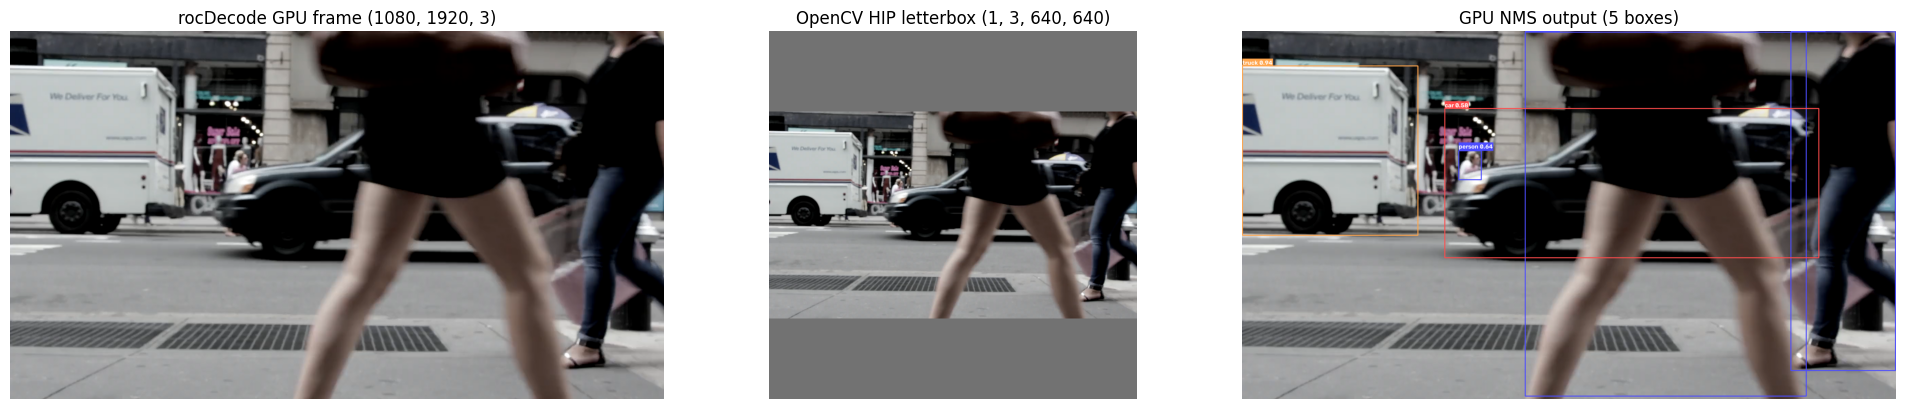

**Resident inference:** P50 `6.97 ms`, P95 `7.01 ms`; input/output pointers stayed stable. The two `.cpu()` copies above exist only to render this teaching figure.

In [28]:
import cv2
import config as pipeline_config

pipeline_config = importlib.reload(pipeline_config)
pipeline_config.YOLO_MODEL_PATH = str(deployment_onnx)

from detector import UltralyticsYOLODetector
from postprocess import draw_detections
from preprocess import GPUPreprocessor
from video_io import RocDecodeReader

with capture_log(env.OUTPUT / "logs/gpu_resident_path.log", "GPU-resident path"):
    reader = RocDecodeReader(str(env.SOURCE_VIDEO), device_id=0)
    processor = GPUPreprocessor((640, 640), device="cuda:0")
    detector = UltralyticsYOLODetector(model_path=str(deployment_onnx), device_id=0)
    try:
        ok, rgb_gpu = reader.read_gpu()
        assert ok and rgb_gpu.is_cuda
        blob_gpu, scale, pad_w, pad_h = processor.process(rgb_gpu)
        for _ in range(5):
            raw_gpu = detector.infer_gpu(blob_gpu)
        torch.cuda.synchronize()
        resident_samples_ms = []
        input_pointer = blob_gpu.data_ptr()
        output_pointer = raw_gpu.data_ptr()
        for _ in range(30):
            torch.cuda.synchronize()
            started = time.perf_counter()
            raw_gpu = detector.infer_gpu(blob_gpu)
            torch.cuda.synchronize()
            resident_samples_ms.append((time.perf_counter() - started) * 1000)
            assert blob_gpu.data_ptr() == input_pointer
            assert raw_gpu.data_ptr() == output_pointer
        detections = detector._parse_gpu(
            raw_gpu, scale, pad_w, pad_h, tuple(rgb_gpu.shape)
        )
        decoded_rgb = rgb_gpu.cpu().numpy()
        model_input_rgb = (
            blob_gpu[0].permute(1, 2, 0).clamp(0, 1).mul(255).byte().cpu().numpy()
        )
    finally:
        reader.release()

resident_inference = {
    "p50_ms": round(statistics.median(resident_samples_ms), 3),
    "p95_ms": round(percentile(resident_samples_ms, 0.95), 3),
    "input_pointer": input_pointer,
    "output_pointer": output_pointer,
}
decoded_bgr = cv2.cvtColor(decoded_rgb, cv2.COLOR_RGB2BGR)
model_input_bgr = cv2.cvtColor(model_input_rgb, cv2.COLOR_RGB2BGR)
production_plot = decoded_bgr.copy()
draw_detections(production_plot, detections, names=detector.names)
show_bgr_grid(
    [decoded_bgr, model_input_bgr, production_plot],
    [
        f"rocDecode GPU frame {tuple(rgb_gpu.shape)}",
        f"OpenCV HIP letterbox {tuple(blob_gpu.shape)}",
        f"GPU NMS output ({len(detections)} boxes)",
    ],
    columns=3,
)
display(Markdown(
    f"**Resident inference:** P50 `{resident_inference['p50_ms']:.2f} ms`, "
    f"P95 `{resident_inference['p95_ms']:.2f} ms`; input/output pointers stayed stable. "
    "The two `.cpu()` copies above exist only to render this teaching figure."
))
assert blob_gpu.device.type == "cuda" and raw_gpu.device.type == "cuda"

production_detections = list(detections)
production_names = detector.names
del detector, processor, raw_gpu, blob_gpu, rgb_gpu
gc.collect()
torch.cuda.empty_cache()

## 6. Protect correctness before optimizing further

The convenience path and production path use different letterbox implementations, so byte-identical boxes are not required. They must retain the same box count and classes, with class-matched IoU above 0.90. A faster path that fails this gate is not an optimization.

Prediction parity: complete (full log: /workspace/output/step_by_step/logs/predict_production_parity.log)


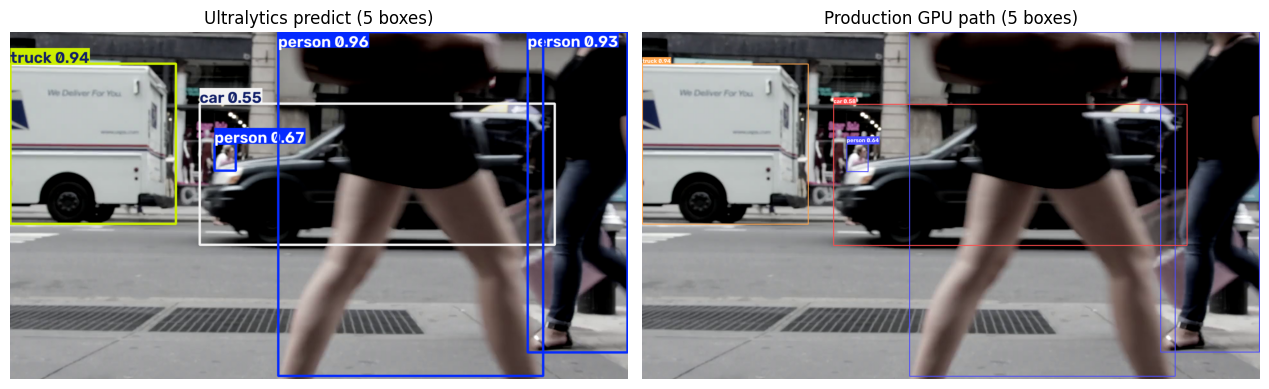

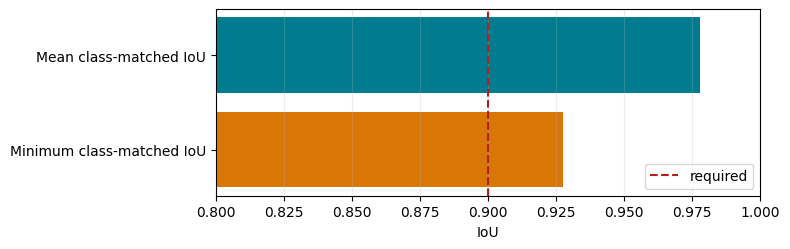

**Parity PASS:** minimum class-matched IoU `0.9275` >= `0.90`.

In [29]:
from tests.test_predict_production_parity import validate as validate_parity

with capture_log(env.OUTPUT / "logs/predict_production_parity.log", "Prediction parity"):
    parity = validate_parity(deployment_onnx, env.SOURCE_VIDEO, minimum_iou=0.90)

reference_plot = result_plot.copy()
production_parity_plot = first_frame.copy()
draw_detections(production_parity_plot, production_detections, names=production_names)
show_bgr_grid(
    [reference_plot, production_parity_plot],
    [
        f"Ultralytics predict ({parity['predict_boxes']} boxes)",
        f"Production GPU path ({parity['production_boxes']} boxes)",
    ],
    columns=2,
)
figure, axis = plt.subplots(figsize=(8, 2.6))
axis.barh(
    ["Minimum class-matched IoU", "Mean class-matched IoU"],
    [parity["minimum_class_matched_iou"], parity["mean_class_matched_iou"]],
    color=["#d97706", "#007c91"],
)
axis.axvline(parity["minimum_required_iou"], color="#b91c1c", linestyle="--", label="required")
axis.set_xlim(0.8, 1.0)
axis.set_xlabel("IoU")
axis.legend()
axis.grid(axis="x", alpha=0.25)
figure.tight_layout()
plt.show()
display(Markdown(
    f"**Parity PASS:** minimum class-matched IoU "
    f"`{parity['minimum_class_matched_iou']:.4f}` >= `{parity['minimum_required_iou']:.2f}`."
))
gc.collect()
torch.cuda.empty_cache()

## 7. Measure every GPU-resident stage

This benchmark separates rocDecode, OpenCV HIP preprocessing, Ultralytics/MIGraphX inference, and OpenCV GPU NMS. It synchronizes every stage, reports mean/P50/P95 after warmup, and fails if any reusable pointer changes.

The benchmark excludes overlay and encoded-video transport. Its FPS is therefore a stage-boundary measurement, not the final video FPS.

GPU stage benchmark: complete (full log: /workspace/output/step_by_step/logs/gpu_stage_benchmark.log)
Warnings:
- [ERR]  {GetWidth}  Display width is 0.
- [ERR]  {GetHeight}  Display height is 0.


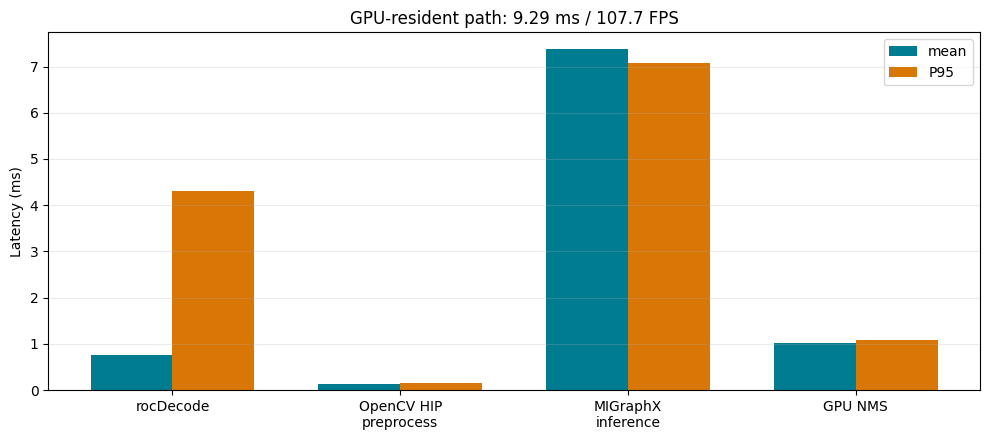

**Stable allocations:** `5` tracked pointers; all stayed unchanged across `120` measured frames.

In [30]:
from tests.benchmark_gpu_stages import benchmark

RUN_BENCHMARK = os.environ.get("RUN_BENCHMARK", "0") == "1"
benchmark_path = env.OUTPUT / f"benchmarks/gpu_stages_{deployment_sha256[:12]}.json"
if RUN_BENCHMARK or not benchmark_path.is_file():
    with capture_log(env.OUTPUT / "logs/gpu_stage_benchmark.log", "GPU stage benchmark"):
        gpu_benchmark = benchmark(
            env.SOURCE_VIDEO,
            frames=120,
            warmup=10,
            model_path=deployment_onnx,
        )
    benchmark_path.parent.mkdir(parents=True, exist_ok=True)
    benchmark_path.write_text(json.dumps(gpu_benchmark, indent=2) + "\n")
else:
    gpu_benchmark = json.loads(benchmark_path.read_text())
    print(f"GPU stage benchmark: reused {benchmark_path}")

stage_names = ["decode", "preprocess", "inference", "gpu_nms"]
stage_labels = ["rocDecode", "OpenCV HIP\npreprocess", "MIGraphX\ninference", "GPU NMS"]
means = [gpu_benchmark["stages"][name]["mean_ms"] for name in stage_names]
p95s = [gpu_benchmark["stages"][name]["p95_ms"] for name in stage_names]
figure, axis = plt.subplots(figsize=(10, 4.5))
positions = range(len(stage_names))
axis.bar([value - 0.18 for value in positions], means, width=0.36, label="mean", color="#007c91")
axis.bar([value + 0.18 for value in positions], p95s, width=0.36, label="P95", color="#d97706")
axis.set_xticks(list(positions), stage_labels)
axis.set_ylabel("Latency (ms)")
axis.set_title(f"GPU-resident path: {gpu_benchmark['gpu_path_mean_ms']:.2f} ms / {gpu_benchmark['gpu_path_fps']:.1f} FPS")
axis.grid(axis="y", alpha=0.25)
axis.legend()
figure.tight_layout()
plt.show()
display(Markdown(
    f"**Stable allocations:** `{len(gpu_benchmark['stable_pointers'])}` tracked pointers; "
    f"all stayed unchanged across `{gpu_benchmark['frames']}` measured frames."
))

## 8. Build the optimization ladder

Optimization should remove the largest repeated boundary first, then remeasure the whole relevant path:

1. **Static ONNX + MIGraphX FP16 cache** removes repeated graph interpretation and compilation.
2. **Pinned host memory** enables asynchronous DMA when a host input is unavoidable.
3. **rocDecode + DLPack** removes full-frame H2D from file decode.
4. **OpenCV HIP preprocessing** avoids a GPU-frame D2H followed by a model-input H2D.
5. **Stable buffers + ORT I/O Binding** remove model input/output round trips and allocation churn.
6. **GPU confidence filtering + NMS** reduces D2H to compact surviving detections.
7. **HIP overlay + direct VA-API** removes the full-frame D2H/raw-video pipe before encode.
8. **Sparse, separately timed VLM calls** prevent a hundreds-of-milliseconds semantic stage from defining per-frame detector throughput.

Pinned memory improves transfer mechanics; GPU residency removes the transfer. Prefer removal when the surrounding APIs allow it.

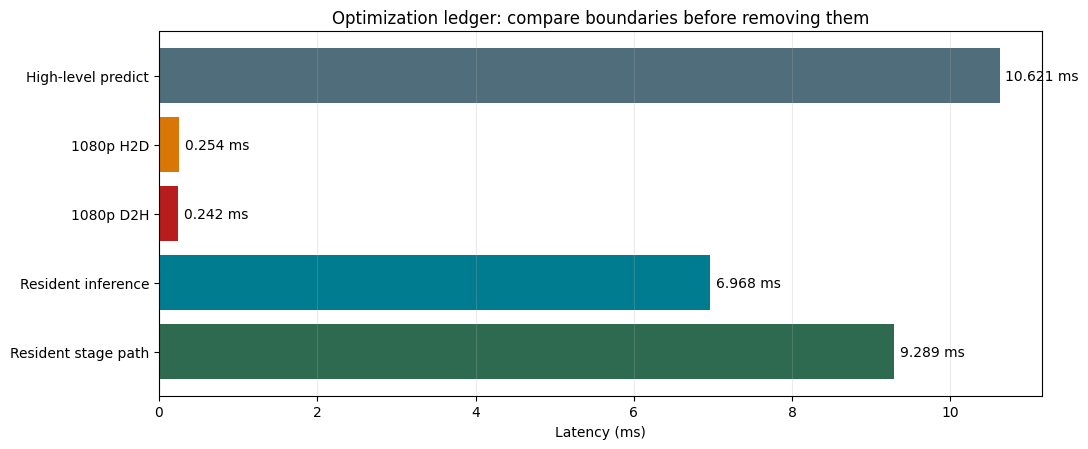

,measurement,scope,lesson
0,High-level predict,CPU image -> Results,Convenient baseline; includes more than inference
1,1080p H2D,One full RGB frame,Remove with GPU decode
2,1080p D2H,One full RGB frame,Copy compact metadata instead
3,Resident inference,GPU input -> GPU output,Stable I/O Binding isolates execution
4,Resident stage path,Decode -> GPU NMS,Relevant boundary before overlay/encode


In [31]:
full_frame_transfers = transfer_table[transfer_table["payload"] == "1080p RGB frame"]
pageable_h2d = full_frame_transfers[
    (full_frame_transfers["direction"] == "H2D")
    & (full_frame_transfers["host_memory"] == "pageable")
].iloc[0]
pageable_d2h = full_frame_transfers[
    (full_frame_transfers["direction"] == "D2H")
    & (full_frame_transfers["host_memory"] == "pageable")
].iloc[0]

optimization_ledger = pd.DataFrame([
    {
        "measurement": "High-level predict",
        "p50_ms": backend_timing["steady_predict_p50_ms"],
        "scope": "CPU image -> Results",
        "lesson": "Convenient baseline; includes more than inference",
    },
    {
        "measurement": "1080p H2D",
        "p50_ms": pageable_h2d["p50_ms"],
        "scope": "One full RGB frame",
        "lesson": "Remove with GPU decode",
    },
    {
        "measurement": "1080p D2H",
        "p50_ms": pageable_d2h["p50_ms"],
        "scope": "One full RGB frame",
        "lesson": "Copy compact metadata instead",
    },
    {
        "measurement": "Resident inference",
        "p50_ms": resident_inference["p50_ms"],
        "scope": "GPU input -> GPU output",
        "lesson": "Stable I/O Binding isolates execution",
    },
    {
        "measurement": "Resident stage path",
        "p50_ms": gpu_benchmark["gpu_path_mean_ms"],
        "scope": "Decode -> GPU NMS",
        "lesson": "Relevant boundary before overlay/encode",
    },
])
figure, axis = plt.subplots(figsize=(11, 4.6))
colors = ["#4f6d7a", "#d97706", "#b91c1c", "#007c91", "#2d6a4f"]
bars = axis.barh(optimization_ledger["measurement"], optimization_ledger["p50_ms"], color=colors)
axis.invert_yaxis()
axis.bar_label(bars, fmt="%.3f ms", padding=4)
axis.set_xlabel("Latency (ms)")
axis.set_title("Optimization ledger: compare boundaries before removing them")
axis.grid(axis="x", alpha=0.25)
figure.tight_layout()
plt.show()
display(optimization_ledger[["measurement", "scope", "lesson"]])

## 9. Measure VLM input and output separately

The released workflow keeps Qwen3-VL as a separate scene-analysis pass. Every four-second segment becomes one three-frame storyboard, one HTTP request, and one caption. This is not detector-driven reasoning, and its latency must not be folded into YOLO FPS.

The cell displays exactly what the VLM received and what it returned. Set `RUN_VLM_LIVE=1` to repeat the first request against the persistent llama.cpp service; otherwise it reuses the verified timeline.

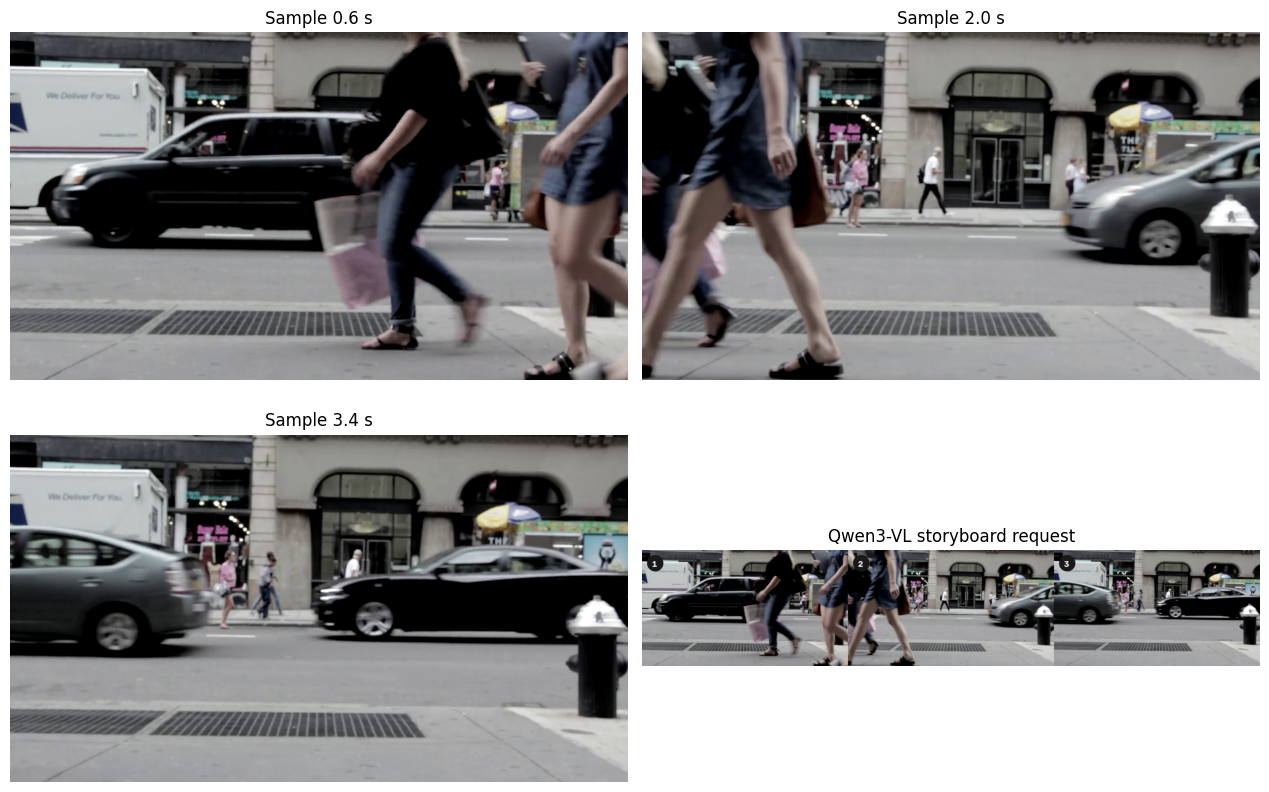

**Qwen3-VL output** (0.390 s, verified timeline):  Pedestrians cross street as cars pass by in urban setting.

In [32]:
from scripts import pipeline_workflow as workflow
workflow = importlib.reload(workflow)

RUN_VLM_LIVE = os.environ.get("RUN_VLM_LIVE", "0") == "1"
if not workflow.TIMELINE.is_file():
    with capture_log(env.OUTPUT / "logs/production_workflow.log", "Production workflow"):
        workflow_result = workflow.run_workflow(force=False)

timeline = json.loads(workflow.TIMELINE.read_text())
first_segment = timeline["segments"][0]
storyboard_path = workflow.RUN_DIR / first_segment["storyboard"]
storyboard = cv2.imread(str(storyboard_path))
assert storyboard is not None
sample_frames = [frame_at(env.SOURCE_VIDEO, seconds) for seconds in first_segment["sample_times"]]
show_bgr_grid(
    [*sample_frames, storyboard],
    [
        *[f"Sample {seconds:.1f} s" for seconds in first_segment["sample_times"]],
        "Qwen3-VL storyboard request",
    ],
    columns=2,
)

vlm_record = {
    "backend": timeline["backend"],
    "model": timeline["model"],
    "interval_seconds": timeline["interval_seconds"],
    "input": str(storyboard_path),
    "sample_times": first_segment["sample_times"],
    "output": first_segment["caption"],
    "latency_seconds": first_segment["latency_seconds"],
    "source": "verified timeline",
}
if RUN_VLM_LIVE:
    from vlm_client import LlamaCppVLMClient

    with capture_log(env.OUTPUT / "logs/vlm_live_request.log", "Live VLM request"):
        client = LlamaCppVLMClient(base_url=env.LLAMACPP_BASE_URL)
        assert client.health_check()
        started = time.perf_counter()
        live_output = client.describe_roi(storyboard, timeline["prompt"])
    vlm_record.update({
        "output": live_output,
        "latency_seconds": round(time.perf_counter() - started, 3),
        "source": "live request",
    })
display(Markdown(
    f"**Qwen3-VL output** ({vlm_record['latency_seconds']:.3f} s, {vlm_record['source']}):  "
    f"{vlm_record['output']}"
))

## 10. Connect the optimized stages to the unchanged production workflow

The production command still runs the released YOLO-only GPU path. It forces rocDecode and `vaapi-direct`: a bounded worker queue holds the resident RGB tensor, then a dedicated HIP stream performs RGB-to-NV12, box/text overlay, and submission to a DRM PRIME VA-API surface.

This final step runs or reuses the unchanged production workflow, then shows both the GPU-resident YOLO video and the rendered Qwen3-VL result. Detailed pipeline output remains in the artifact logs instead of filling the Notebook.

Production video workflow: reused verified artifacts


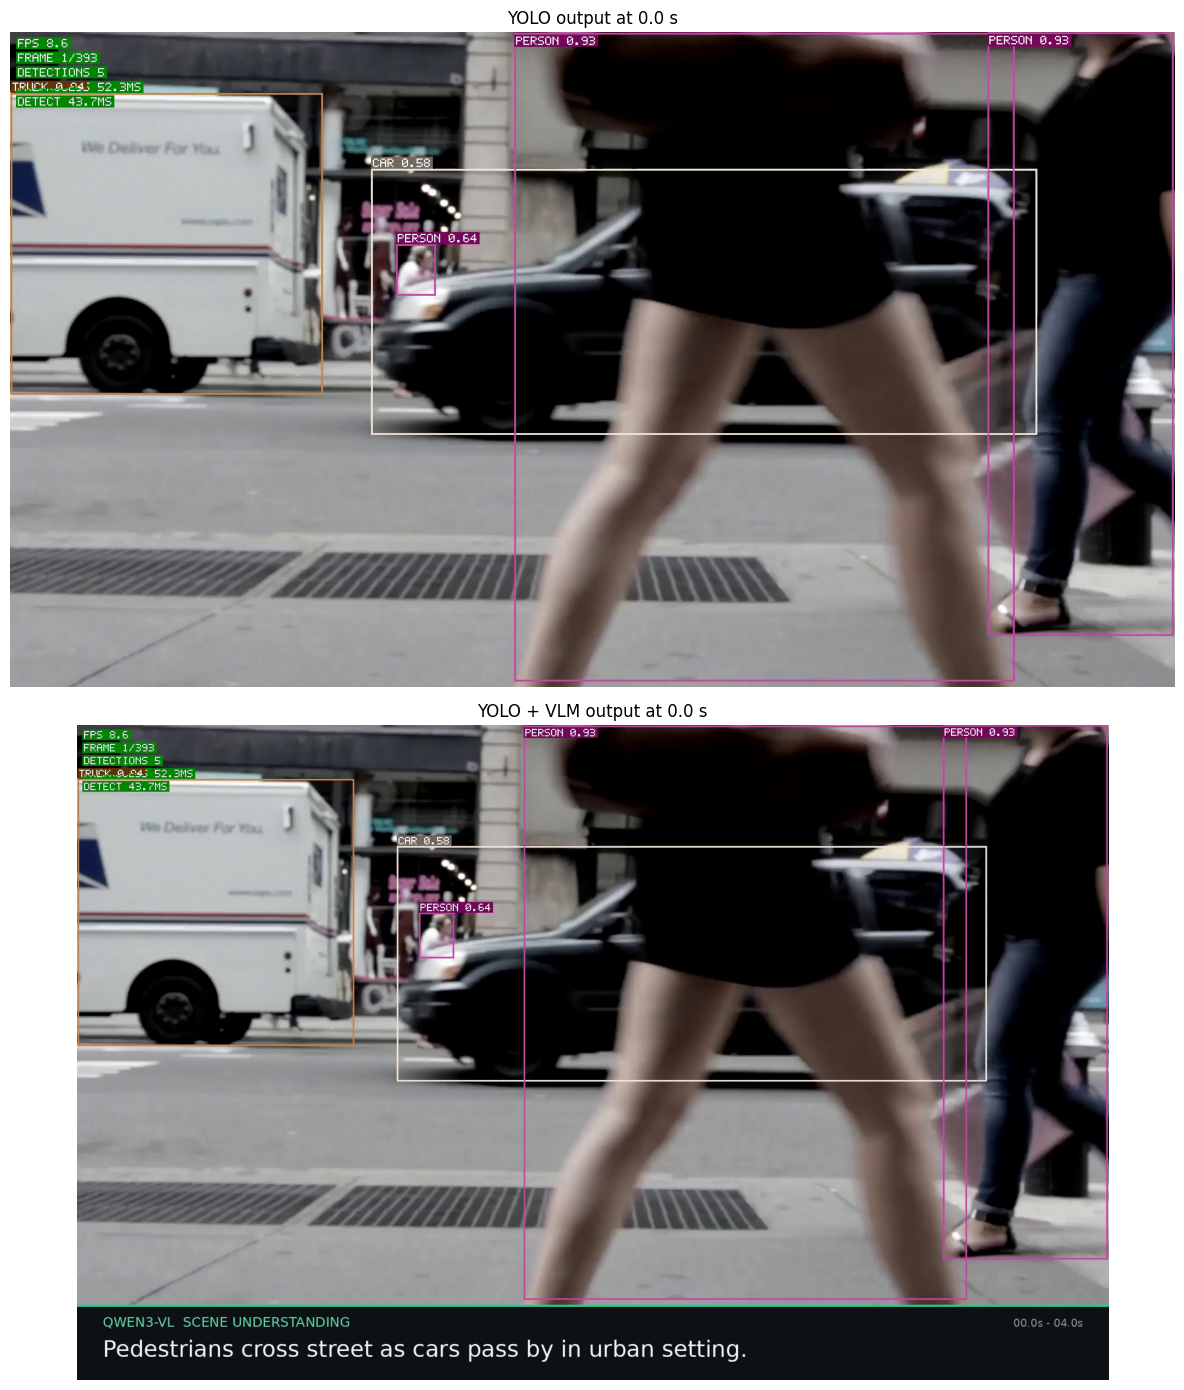

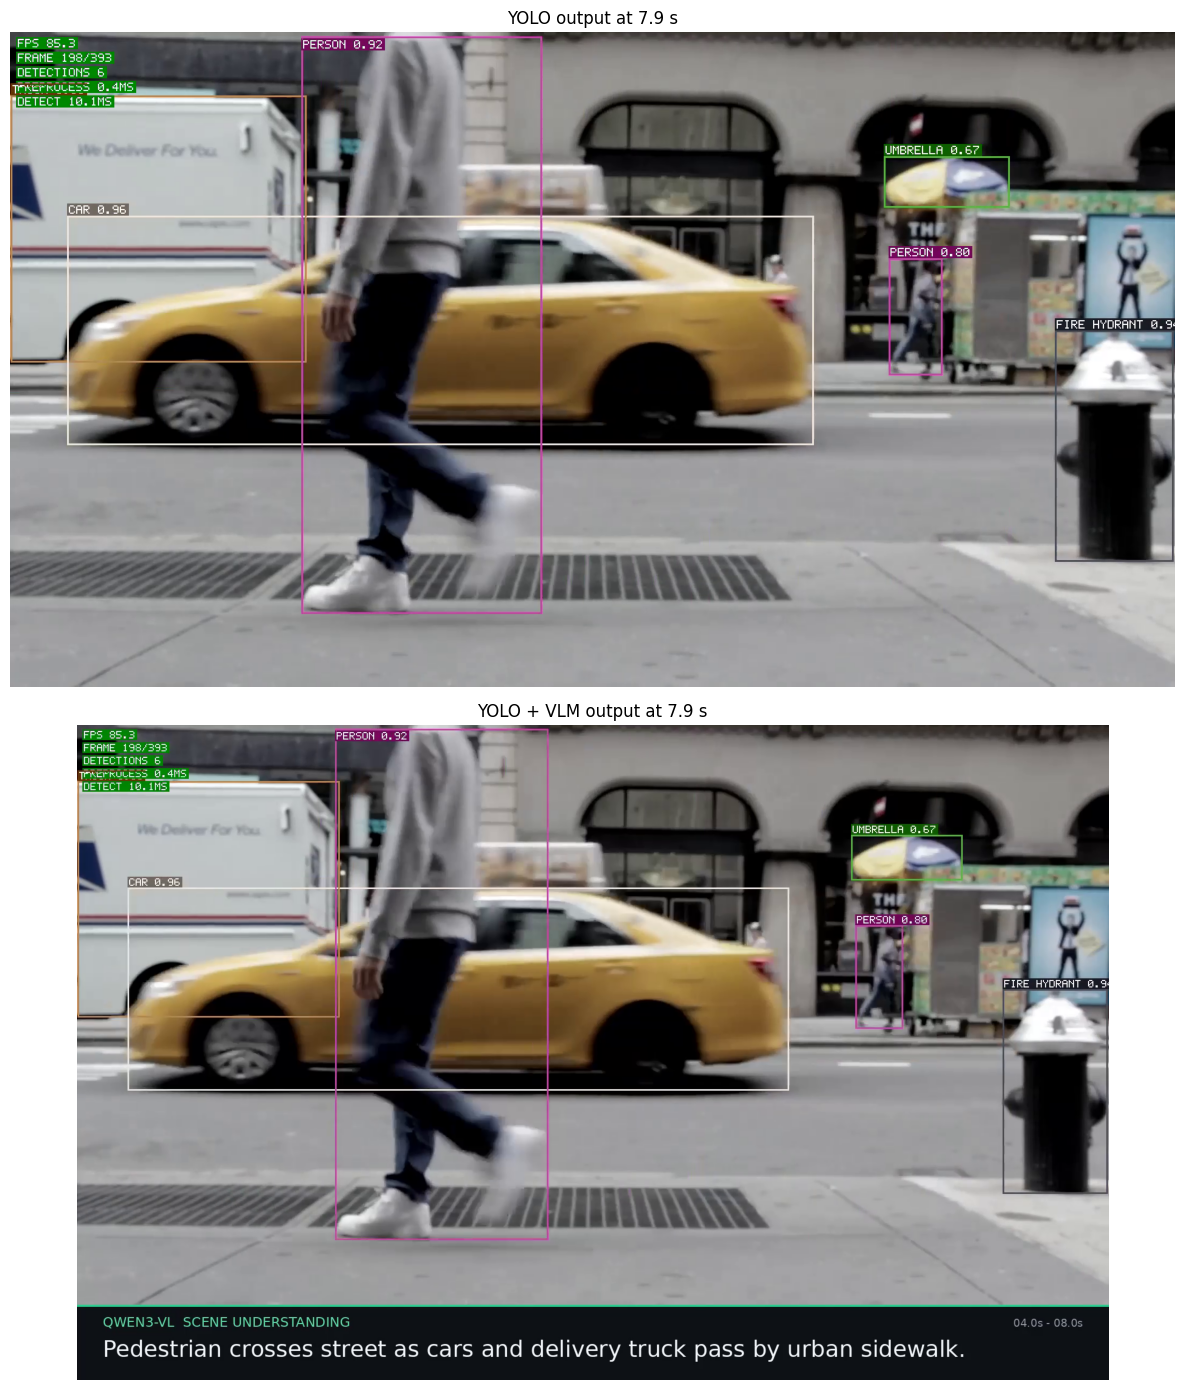

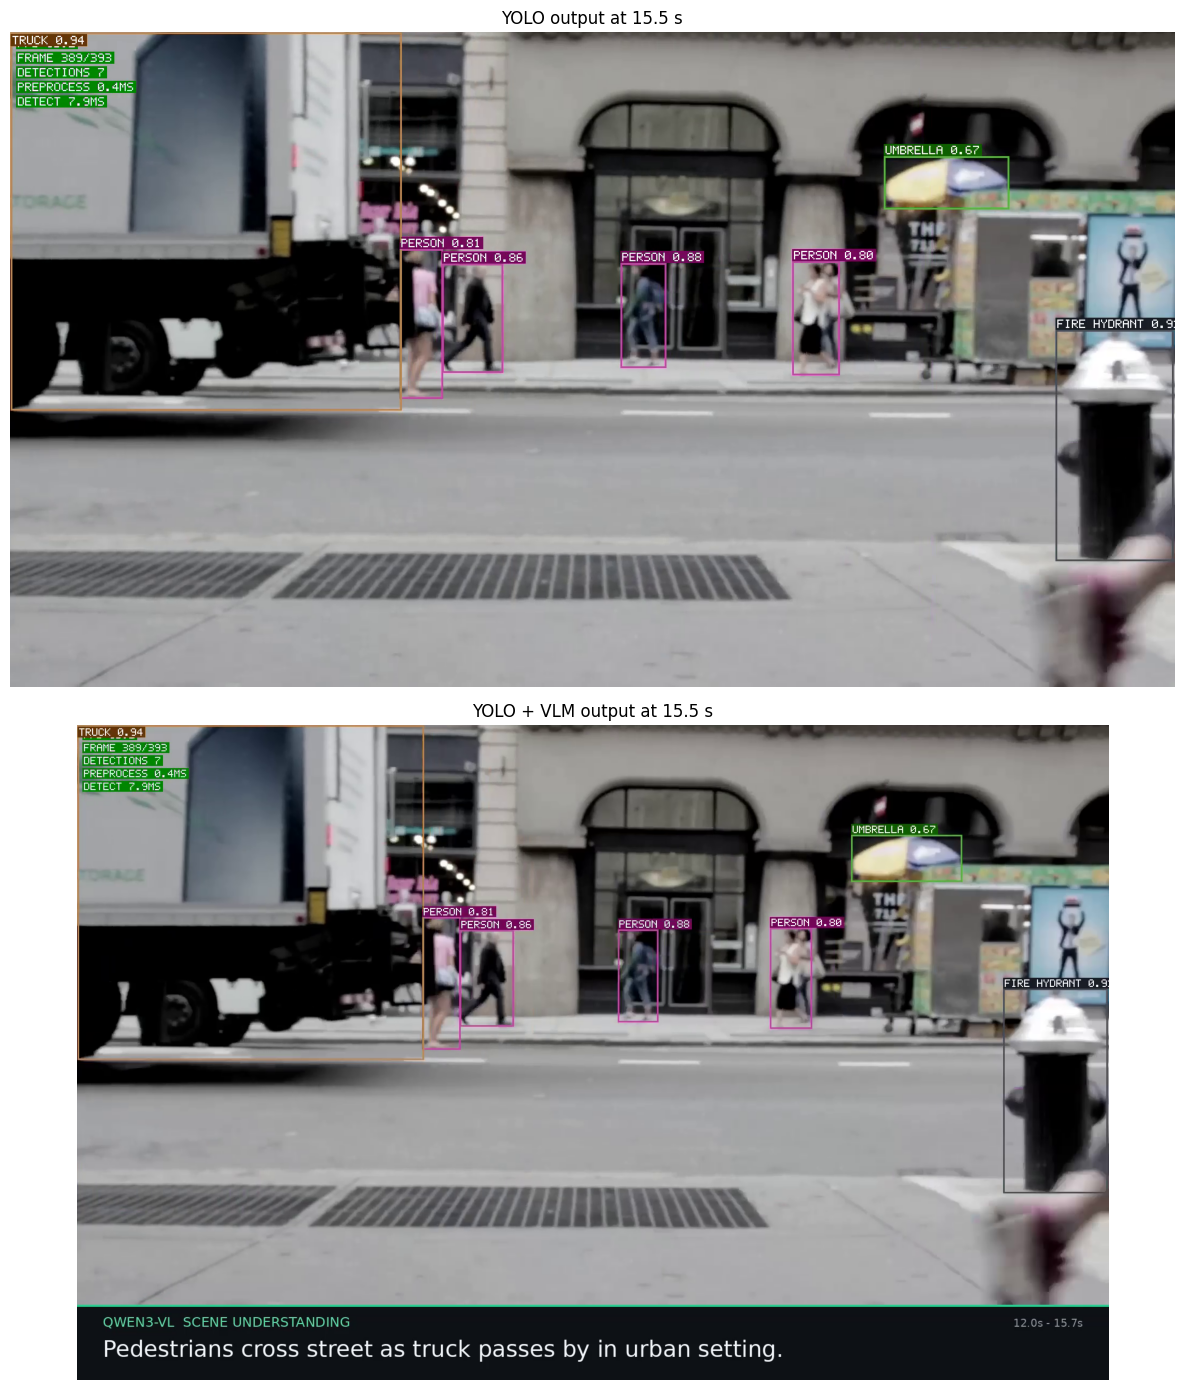

**Production result:** `94.8 FPS`; full-frame D2H `0.00 ms`; submitted/encoded frames `393/393`.

In [33]:
from scripts import pipeline_workflow as workflow
workflow = importlib.reload(workflow)

RUN_PIPELINE = os.environ.get("RUN_PIPELINE", "0") == "1"
os.environ["ULTRALYTICS_MIGRAPHX_CACHE_ROOT"] = str(env.MIGRAPHX_CACHE)
outputs_ready = all(path.is_file() for path in workflow.required_outputs())
identity_ready, _ = workflow.manifest_matches_current()
if RUN_PIPELINE or not (outputs_ready and identity_ready):
    with capture_log(env.OUTPUT / "logs/production_workflow.log", "Production video workflow"):
        workflow_result = workflow.run_workflow(force=RUN_PIPELINE)
else:
    workflow_result = workflow.validate_outputs()
    print("Production video workflow: reused verified artifacts")
manifest = json.loads(workflow.MANIFEST.read_text())
performance = manifest["pipeline"]["performance"]

yolo_times = [0.0, source_info["duration_seconds"] / 2, max(0.0, source_info["duration_seconds"] - 0.2)]
yolo_frames = [frame_at(workflow.YOLO_VIDEO, seconds) for seconds in yolo_times]
final_frames = [frame_at(workflow.FINAL_VIDEO, seconds) for seconds in yolo_times]
for seconds, yolo_frame, final_frame in zip(yolo_times, yolo_frames, final_frames):
    show_bgr_grid(
        [yolo_frame, final_frame],
        [
            f"YOLO output at {seconds:.1f} s",
            f"YOLO + VLM output at {seconds:.1f} s",
        ],
        columns=1,
        size=(16, 14),
    )
show_video(workflow.YOLO_VIDEO, "YOLO26 GPU-resident detection video")
show_video(workflow.FINAL_VIDEO, "Final YOLO26 + Qwen3-VL video")
display(Markdown(
    f"**Production result:** `{performance['fps']:.1f} FPS`; full-frame D2H "
    f"`{performance['frame_d2h_ms']:.2f} ms`; submitted/encoded frames "
    f"`{performance['direct_encode_submitted_frames']}/{performance['direct_encode_encoded_frames']}`."
))

## 11. Copy audit and takeaways

### Final YOLO/no-VLM production path

```text
H.264
  -> rocDecode GPU frame
  -> OpenCV HIP preprocess
  -> Ultralytics / ORT MIGraphX FP16 with I/O Binding
  -> OpenCV GPU filtering and NMS
  -> compact detections D2H
  -> HIP overlay + RGB-to-NV12
  -> direct VA-API H.264 encode
```

There is no full-frame D2H in this path. Compact boxes/classes/scores cross to the host after GPU NMS. Notebook visualization, the JPEG/HTTP VLM input, and the subtitle renderer remain explicit host boundaries.

### Optimization method

1. Define the measurement boundary.
2. Warm up compilation and caches.
3. Synchronize asynchronous hardware before stopping a latency timer.
4. Separate model execution from preprocessing, postprocessing, and transport.
5. Remove repeated full-frame copies before micro-optimizing kernels.
6. Reuse allocations and verify pointer stability.
7. Protect every optimization with a parity or artifact-integrity gate.
8. Report P50/P95 and environment load, not only the best FPS.

**Takeaway:** moving a model to the GPU is only the first step. A fast pipeline keeps data on the right device, moves only compact results, overlaps independent work, and measures the entire boundary it claims to optimize.